In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. ĐỌC DỮ LIỆU TỪ FILE TRAIN CỦA BẠN
# ==============================================================================
df = pd.read_csv('train.csv')
print(f"Kích thước file train gốc: {df.shape}")

# Chuẩn hóa đặt lại tên cột (xóa khoảng trắng thừa)
df.columns = df.columns.str.strip().str.replace(' ', '_')

# ==============================================================================
# 2. LOẠI BỎ CỘT KHÔNG DÙNG ĐẾN
# ==============================================================================
df_cleaned = df.drop(columns=[
    "Address", "Propertycount", "Method", 
    "SellerG", "Postcode", "CouncilArea"
], errors='ignore')

# ==============================================================================
# 3. KIỂM TRA VÀ XỬ LÝ DỮ LIỆU THIẾU
# ==============================================================================
null_count = df_cleaned.isnull().sum()
null_percent = (df_cleaned.isnull().mean() * 100).round(3)
missing_values = pd.DataFrame({
    'Số lượng null': null_count,
    'Phần trăm null (%)': null_percent
})
print("\nTỉ lệ giá trị thiếu trong mỗi cột trước khi xử lý:")
print(missing_values.sort_values(by='Số lượng null', ascending=False))

# Drop những cột thiếu khoảng từ 40%
df_cleaned = df_cleaned.drop(columns=["BuildingArea", "YearBuilt"], errors='ignore') 

# Các cột còn lại thiếu không quá 0.5% -> Dropna xóa hàng khuyết
df_cleaned = df_cleaned.dropna() 
print("\n[OK] Đã xử lý xong missing values.")

# ==============================================================================
# 4. XỬ LÝ DỮ LIỆU BẤT HỢP LÝ
# ==============================================================================
Handled_columns = ["Rooms", "Price", "Landsize"]
for col in Handled_columns:
    if col in df_cleaned.columns:
        df_cleaned = df_cleaned[df_cleaned[col] > 0]
print("[OK] Đã xử lý xong dữ liệu bất hợp lý (Lọc giá trị > 0).")

# ==============================================================================
# 5. KIỂM TRA VÀ XỬ LÝ DỮ LIỆU TRÙNG LẶP
# ==============================================================================
duplicates = df_cleaned.duplicated().sum()
print(f"Số lượng bản ghi trùng lặp: {duplicates}")
df_cleaned = df_cleaned.drop_duplicates()
print("[OK] Đã xử lý trùng lặp.")

# ==============================================================================
# 6. CHUẨN HÓA KIỂU DỮ LIỆU & TRÍCH XUẤT THỜI GIAN
# ==============================================================================
int_cols = ["Rooms", "Bedroom2", "Bathroom", "Car"]
for col in int_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].astype(int)

df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], dayfirst=True)
df_cleaned["year"] = df_cleaned["Date"].dt.year
df_cleaned["month"] = df_cleaned["Date"].dt.month
print("[OK] Chuẩn hóa kiểu số nguyên và tạo biến year, month thành công.")

# ==============================================================================
# 7. XỬ LÝ BIẾN SUBURB VÀ REGIONNAME (GOM NHÓM HIẾM)
# ==============================================================================
# Đưa những khu vực (Suburb) với không quá 10 giao dịch BĐS thành nhóm Other
Suburb_stats = df_cleaned['Suburb'].value_counts(ascending=False)
Suburb_stats_less_than_10 = Suburb_stats[Suburb_stats <= 10]
print(f"Số lượng khu vực với không quá 10 giao dịch: {len(Suburb_stats_less_than_10)}")

df_cleaned['Suburb'] = df_cleaned['Suburb'].apply(lambda x: 'Other' if x in Suburb_stats_less_than_10 else x)
print(f"Số lượng khu vực sau khi xử lý phân nhóm: {len(df_cleaned['Suburb'].unique())}\n")

# Lọc bỏ những dòng thuộc các vùng miền hiếm giao dịch
dropped_region = ['Eastern Victoria', 'Northern Victoria', 'Western Victoria']
df_cleaned = df_cleaned[~df_cleaned['Regionname'].isin(dropped_region)]

# ==============================================================================
# 8. MÃ HÓA ONE-HOT ENCODING (ĐÃ SỬA LỖI ĐỊNH DẠNG BOOLEAN & ĐÚNG TÊN CỘT)
# ==============================================================================
# Đối với Type (Ép kiểu int để ra số 0 và 1 thay vì True/False)
dummy_variable1 = pd.get_dummies(df_cleaned["Type"], dtype=int)
dummy_variable1.rename(columns={'h': 'Type_h', 't': 'Type_t', 'u': 'Type_u'}, inplace=True)
df_cleaned = pd.concat([df_cleaned, dummy_variable1], axis=1)

# Đối với Regionname (Ép kiểu int để ra số 0 và 1)
dummy_variable2 = pd.get_dummies(df_cleaned["Regionname"], dtype=int)
dummy_variable2.rename(columns={
    'Northern Metropolitan': 'Region_NM',
    'Western Metropolitan': 'Region_WM',
    'Southern Metropolitan': 'Region_SM',
    'Eastern Metropolitan': 'Region_EM',
    'South-Eastern Metropolitan': 'Region_SEM'
}, inplace=True)
df_cleaned = pd.concat([df_cleaned, dummy_variable2], axis=1)

# Xóa bớt 2 cột chữ gốc sau khi dập dummy để tránh bị trùng lặp dữ liệu
df_cleaned = df_cleaned.drop(columns=["Type", "Regionname"], errors='ignore')

# ==============================================================================
# 9. TẠO FILE MỚI NHÉT DỮ LIỆU SẠCH VÀO
# ==============================================================================
output_file = "melbourne_housing_cleaned.csv"
df_cleaned.to_csv(output_file, index=False)

print("\n" + "="*65)
print(f"[XONG CELL 1] Đã tạo file mới thành công: '{output_file}'")
print(f"Kích thước file dữ liệu mới: {df_cleaned.shape}")
print("="*65)

Kích thước file train gốc: (34857, 21)

Tỉ lệ giá trị thiếu trong mỗi cột trước khi xử lý:
              Số lượng null  Phần trăm null (%)
BuildingArea          21115              60.576
YearBuilt             19306              55.386
Landsize              11810              33.881
Car                    8728              25.039
Bathroom               8226              23.599
Bedroom2               8217              23.573
Lattitude              7976              22.882
Longtitude             7976              22.882
Price                  7610              21.832
Regionname                3               0.009
Distance                  1               0.003
Date                      0               0.000
Suburb                    0               0.000
Rooms                     0               0.000
Type                      0               0.000

[OK] Đã xử lý xong missing values.
[OK] Đã xử lý xong dữ liệu bất hợp lý (Lọc giá trị > 0).
Số lượng bản ghi trùng lặp: 1
[OK] Đã xử lý trùn

Kích thước trước khi lọc nhiễu (outliers): (15468, 21)

--- ĐANG VẼ BIỂU ĐỒ KIỂM TRA PHÂN PHỐI ---


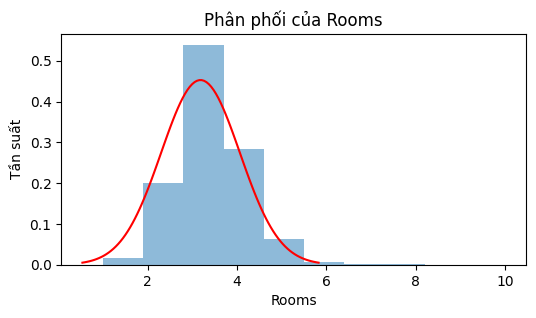

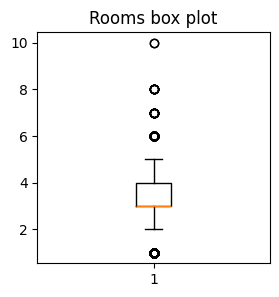

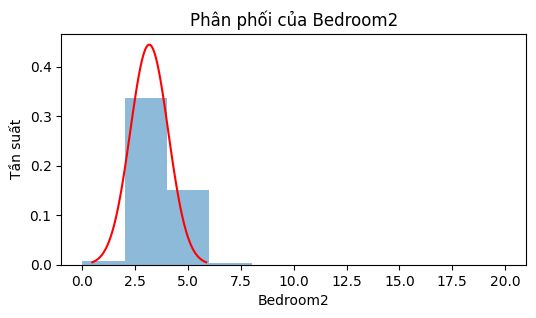

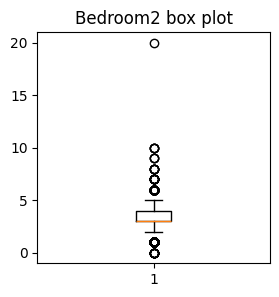

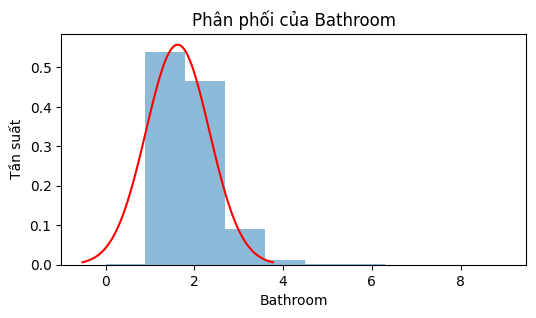

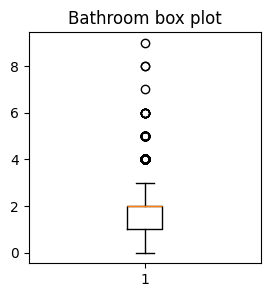

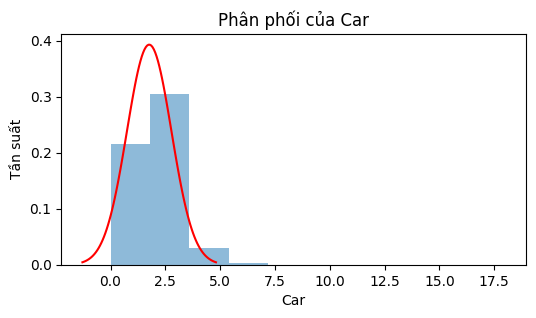

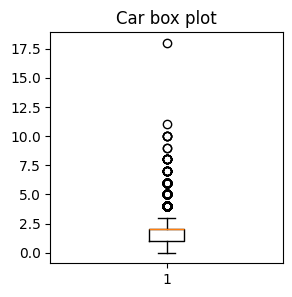

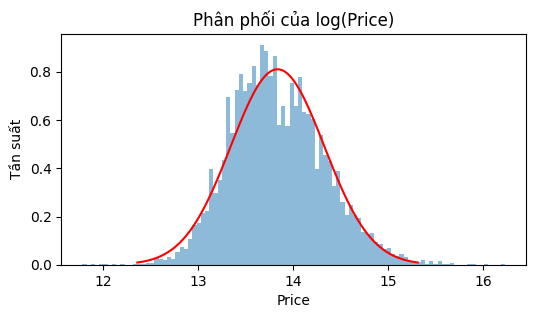

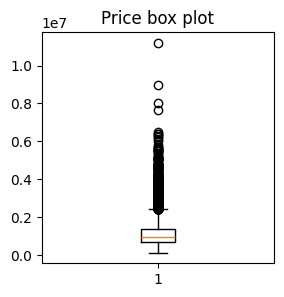

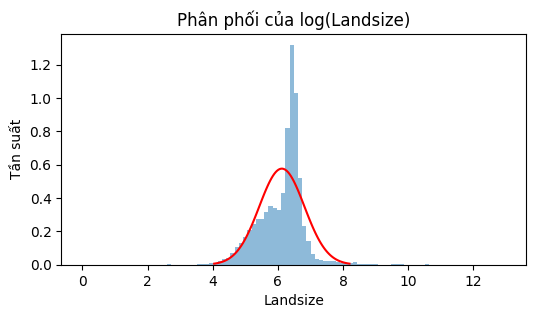

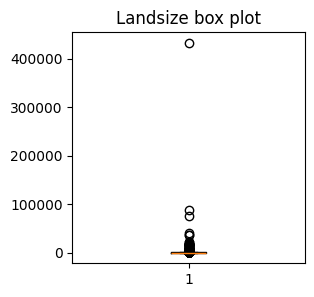

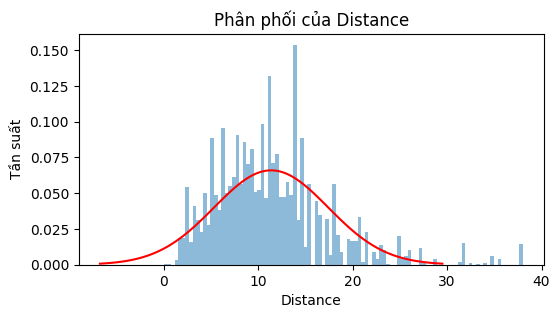

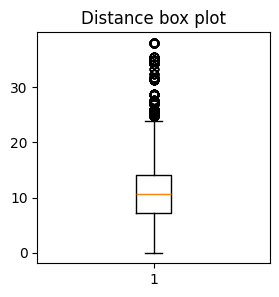


--- TIẾN HÀNH LOẠI BỎ OUTLIERS ---
[OK] Đã lọc xong Outliers bằng Z-score cho: log(Price), Rooms, Bedroom2, Bathroom, Car.
[OK] Đã lọc xong Outliers bằng IQR cho: Landsize, Distance.

[XONG CELL 2] Đã xử lý xong Outliers và cập nhật file: 'melbourne_housing_cleaned.csv'
Kích thước ma trận dữ liệu sau khi loại bỏ nhiễu: (13927, 21)


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Giả sử df_cleaned đã được load thành công từ Cell 1
print(f"Kích thước trước khi lọc nhiễu (outliers): {df_cleaned.shape}")

# ==============================================================================
# PHẦN A: TRỰC QUAN HÓA PHÂN PHỐI (ĐOẠN CODE CỦA BẠN)
# ==============================================================================
print("\n--- ĐANG VẼ BIỂU ĐỒ KIỂM TRA PHÂN PHỐI ---")
numeric_columns1 = ['Rooms', 'Bedroom2', 'Bathroom', 'Car']
numeric_columns2 = ['Price', 'Landsize']

# 1. Vẽ nhóm cột đếm (Rooms, Bedroom2, Bathroom, Car)
for col in numeric_columns1:
    plt.figure(figsize=(6, 3))
    plt.hist(df_cleaned[col], bins=10, density=True, alpha=0.5)
    mean = np.mean(df_cleaned[col])
    std = np.std(df_cleaned[col])
    x = np.linspace(mean - 3*std, mean + 3*std, 100)
    y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
    plt.plot(x, y, color='r')
    plt.xlabel(col)
    plt.ylabel('Tần suất')
    plt.title('Phân phối của ' + col)
    plt.show()

    plt.figure(figsize=(3, 3))
    plt.boxplot(df_cleaned[col])
    plt.title(col + ' box plot')
    plt.show()

# 2. Vẽ nhóm cột liên tục cần lấy Log (Price, Landsize)
for col in numeric_columns2:
    plt.figure(figsize=(6, 3))
    plt.hist(np.log(df_cleaned[col]), bins=100, density=True, alpha=0.5)
    mean = np.mean(np.log(df_cleaned[col]))
    std = np.std(np.log(df_cleaned[col]))
    x = np.linspace(mean - 3*std, mean + 3*std, 100)
    y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
    plt.plot(x, y, color='r')
    plt.xlabel(col)
    plt.ylabel('Tần suất')
    plt.title('Phân phối của log(' + col + ')')
    plt.show()

    plt.figure(figsize=(3, 3))
    plt.boxplot(df_cleaned[col])
    plt.title(col + ' box plot')
    plt.show()

# 3. Vẽ riêng cho thuộc tính Distance
plt.figure(figsize=(6, 3))
plt.hist(df_cleaned["Distance"], bins=100, density=True, alpha=0.5)
mean = np.mean(df_cleaned["Distance"])
std = np.std(df_cleaned["Distance"])
x = np.linspace(mean - 3*std, mean + 3*std, 100)
y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
plt.plot(x, y, color='r')
plt.xlabel("Distance")
plt.ylabel('Tần suất')
plt.title('Phân phối của Distance')
plt.show()

plt.figure(figsize=(3, 3))
plt.boxplot(df_cleaned["Distance"])
plt.title('Distance box plot')
plt.show()


# ==============================================================================
# PHẦN B: THỰC THI LOẠI BỎ OUTLIERS THEO KẾT LUẬN CỦA BẠN
# ==============================================================================
print("\n--- TIẾN HÀNH LOẠI BỎ OUTLIERS ---")

# 1. Áp dụng phương pháp Z-score (ngưỡng |z| <= 3) cho các cột phân phối chuẩn
# Lưu ý: Với Price, ta sẽ tính Z-score dựa trên log(Price) như bạn đã kết luận
z_cols = ['Rooms', 'Bedroom2', 'Bathroom', 'Car']
for col in z_cols:
    mean = df_cleaned[col].mean()
    std = df_cleaned[col].std()
    # Chỉ giữ lại các hàng nằm trong khoảng từ [mean - 3*std] đến [mean + 3*std]
    df_cleaned = df_cleaned[(df_cleaned[col] >= mean - 3*std) & (df_cleaned[col] <= mean + 3*std)]

# Tính Z-score cho log_price
log_price_mean = np.log(df_cleaned['Price']).mean()
log_price_std = np.log(df_cleaned['Price']).std()
df_cleaned = df_cleaned[
    (np.log(df_cleaned['Price']) >= log_price_mean - 3*log_price_std) & 
    (np.log(df_cleaned['Price']) <= log_price_mean + 3*log_price_std)
]
print("[OK] Đã lọc xong Outliers bằng Z-score cho: log(Price), Rooms, Bedroom2, Bathroom, Car.")

# 2. Áp dụng phương pháp IQR (Khoảng biến thiên tứ phân vị) cho các cột còn lại
iqr_cols = ['Landsize', 'Distance']
for col in iqr_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Lọc bỏ dữ liệu vượt quá ranh giới dưới và ranh giới trên
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
print("[OK] Đã lọc xong Outliers bằng IQR cho: Landsize, Distance.")


# ==============================================================================
# PHẦN C: CẬP NHẬT LẠI FILE CSV SẠCH SAU LỌC NHIỄU
# ==============================================================================
output_file = "melbourne_housing_cleaned.csv"
df_cleaned.to_csv(output_file, index=False)

print("\n" + "="*65)
print(f"[XONG CELL 2] Đã xử lý xong Outliers và cập nhật file: '{output_file}'")
print(f"Kích thước ma trận dữ liệu sau khi loại bỏ nhiễu: {df_cleaned.shape}")
print("="*65)